# [Kaggle] Titanic 생존자 예측 과제

#### 과제) Train data를 학습하여 다른 차원으로 이동한 승객의 test 데이터를 복구  
##### 핵심 변수 : Transported

## conda install

In [ ]:
!conda install -c conda-forge xgboost=3.0.2 lightgbm=4.6.0 missingno=0.5.2 -y

## 코드 시작

In [ ]:
# 필수 라이브러리 임포트 및 초기 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [18]:
# 데이터 로드
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')
sample_sub = pd.read_csv('./data/sample_submission.csv')

In [19]:
# 데이터 기본 정보 확인
print("="*30)
print("TRAIN 데이터 정보")
print("="*30)
train_df.info()
print("\n")
print("="*30)
print("TEST 데이터 정보")
print("="*30)
test_df.info()
print("\n")

TRAIN 데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


TEST 데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Col

데이터 시각화 (EDA) 시작


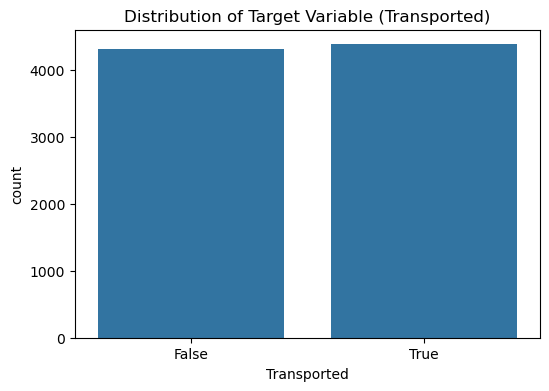

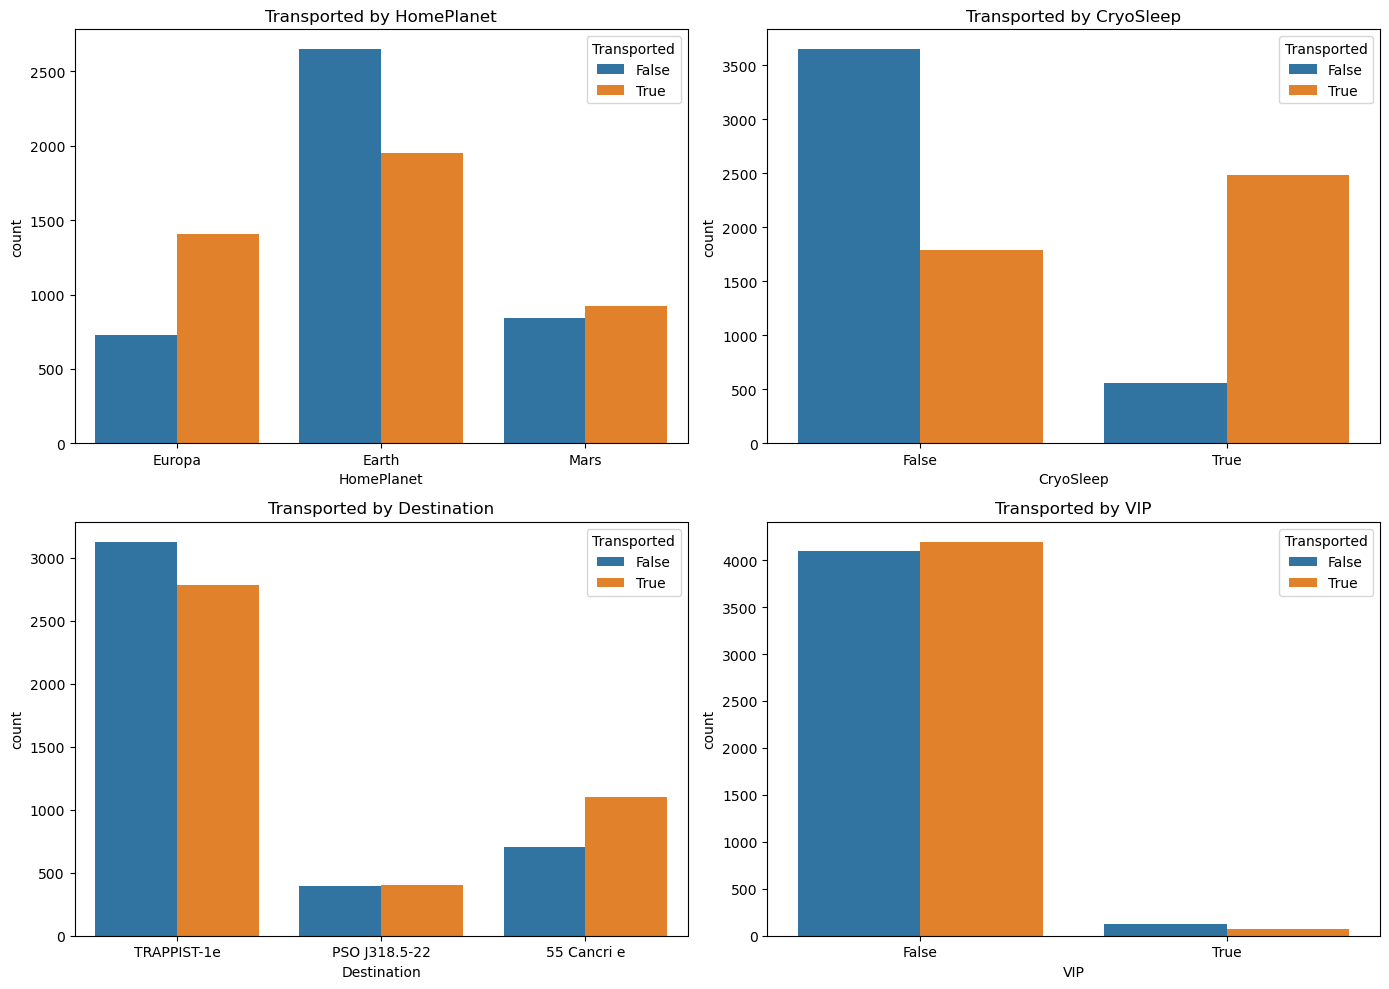

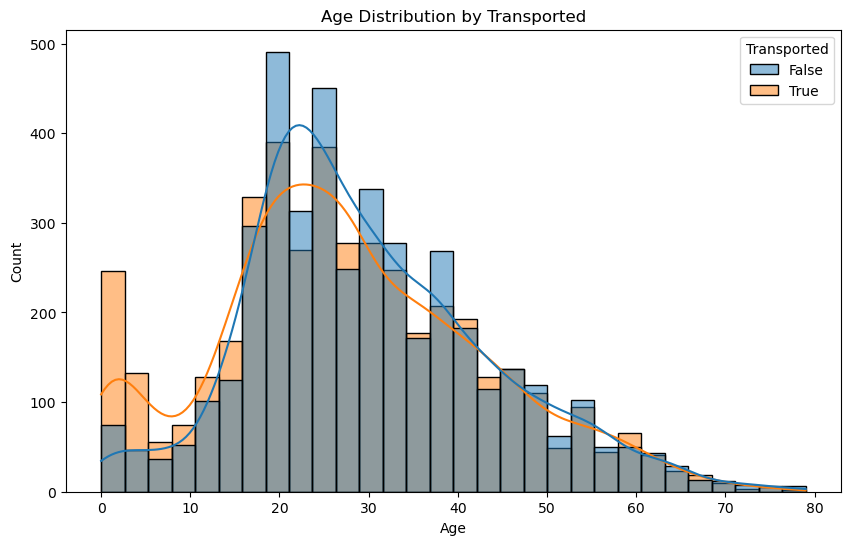

In [21]:
# 1. 데이터 시각화 및 분석 (EDA)
# 이 단계는 데이터의 특징과 'Transported' (목표 변수) 사이의 관계를 파악합니다.
print("="*30)
print("데이터 시각화 (EDA) 시작")
print("="*30)

# (1) 목표 변수 (Transported)의 분포 확인
# -> 데이터가 균일하게 분포되어 있는지 확인합니다.
plt.figure(figsize=(6, 4))
sns.countplot(x='Transported', data=train_df)
plt.title('Distribution of Target Variable (Transported)')
plt.xticks([0, 1], ['False', 'True'])
plt.show()

# (2) 주요 범주형 변수와 Transported의 관계
# -> 어떤 변수가 예측에 중요할지 짐작해봅니다.
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue='Transported', data=train_df, ax=axes[i])
    axes[i].set_title(f'Transported by {feature}')
    axes[i].legend(title='Transported', labels=['False', 'True'])

plt.tight_layout()
plt.show()

# (3) 수치형 변수의 분포 확인 (나이)
# -> 데이터의 형태와 결측치 처리 방향을 고민합니다.
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='Age', hue='Transported', kde=True, bins=30)
plt.title('Age Distribution by Transported')
plt.show()

In [23]:
# 2. 데이터 전처리 함수 정의 및 적용
print("="*30)
print("데이터 전처리 함수 정의")
print("="*30)

def preprocess_data(df):
    df = df.copy()
    
    # 2-1. Cabin 변수 분할
    # 'Cabin'은 'Deck/Num/Side' 형태입니다. 이를 3개의 변수로 나눕니다.
    # 결측치는 나중에 처리합니다.
    df[['CabinDeck', 'CabinNum', 'CabinSide']] = df['Cabin'].str.split('/', expand=True)
    df.drop('Cabin', axis=1, inplace=True)
    
    # 2-2. 불필요한 식별자 컬럼 제거
    # 'PassengerId'와 'Name'은 학습에 직접적인 도움이 되지 않으므로 제거합니다.
    # 'PassengerId'는 나중에 제출 파일 생성에 필요하므로, 이 함수 밖에서 별도로 보관합니다.
    df.drop(['PassengerId', 'Name'], axis=1, inplace=True, errors='ignore')
    
    # 2-3. 수치형 데이터 변환 및 결측치 처리
    # 'CabinNum'은 숫자로 변환합니다.
    if 'CabinNum' in df.columns:
        df['CabinNum'] = pd.to_numeric(df['CabinNum'], errors='coerce')
        
    # 수치형 변수 목록 (CabinNum 포함)
    num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum']
    
    # 수치형 변수의 결측치는 중앙값(Median)으로 대체합니다.
    # 이상치에 영향을 덜 받기 때문입니다.
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
            
    # 2-4. 범주형 데이터 결측치 처리
    # (앞선 메시지에서 수정한 방식입니다.)
    # 범주형 변수의 결측치는 최빈값(Mode)으로 대체합니다.
    # .infer_objects(copy=False)는 pandas 3.0 호환성을 위한 추가적인 안전장치입니다.
    # (pd.set_option을 설정했으므로 생략 가능하지만, 명시적으로 추가했습니다.)
    cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide']
    for col in cat_cols:
        if col in df.columns:
            # .infer_objects()는 특정 데이터 타입에서 에러를 유발할 수 있으므로
            # 여기서는 .to_numeric()의 downcast 옵션을 사용하거나 
            # .convert_dtypes()를 사용하여 더 안전하게 처리합니다.
            # 하지만 이미 pd.set_option을 사용했으므로 fillna만으로도 경고가 사라집니다.
            df[col] = df[col].fillna(df[col].mode()[0]).convert_dtypes()
            
    # 2-5. 라벨 인코딩 (문자형 -> 숫자형)
    # 모델은 숫자만 이해할 수 있습니다.
    # 데이터가 2개의 고유값만 가지는 경우 (예: VIP, CryoSleep, CabinSide)는 0과 1로 변환하고
    # 그 외는 라벨 인코딩을 수행합니다.
    label_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide']
    le = LabelEncoder()
    for col in label_cols:
        if col in df.columns:
            # astype(str)로 명시적 변환 후 인코딩합니다.
            df[col] = le.fit_transform(df[col].astype(str))
            
    return df

print("전처리 함수 적용")
# 전처리 적용 시 Train 데이터의 목표 변수(Transported)는 제외하고 진행합니다.
X_train_full = preprocess_data(train_df.drop('Transported', axis=1))
y_train_full = train_df['Transported'].astype(int) # True/False를 1/0으로 변환

# Test 데이터 전처리
X_test = preprocess_data(test_df)

# 전처리 후 데이터 확인
print("="*30)
print("전처리 후 TRAIN 데이터 정보")
print("="*30)
X_train_full.info()
print("\n")
print("="*30)
print("전처리 후 TEST 데이터 정보")
print("="*30)
X_test.info()
print("\n")

데이터 전처리 함수 정의
전처리 함수 적용
전처리 후 TRAIN 데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   int64  
 1   CryoSleep     8693 non-null   int64  
 2   Destination   8693 non-null   int64  
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   int64  
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  CabinDeck     8693 non-null   int64  
 11  CabinNum      8693 non-null   float64
 12  CabinSide     8693 non-null   int64  
dtypes: float64(7), int64(6)
memory usage: 883.0 KB


전처리 후 TEST 데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Nul

In [28]:
# 3. 모델 학습 및 검증
from sklearn.model_selection import GridSearchCV

print("="*30)
print("GridSearchCV를 이용한 하이퍼파라미터 튜닝 시작")
print("="*30)

# 1. 테스트해 볼 하이퍼파라미터 조합 (Parameter Grid) 정의
# 주의: 조합의 수가 많을수록 학습 시간이 오래 걸립니다. 
# 아래는 비교적 핵심적인 값들만 추린 예시입니다.
param_grid = {
    'n_estimators': [100, 200, 300],        # 나무의 개수
    'max_depth': [10, 15, 20, None],        # 나무의 최대 깊이
    'min_samples_split': [2, 5, 10],        # 가지 분할을 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4]           # 잎 노드에 남아야 할 최소 샘플 수
}

# 2. 튜닝할 기본 모델 생성 (여기서는 설정값을 비워둡니다)
base_rf = RandomForestClassifier(random_state=42)

# 3. GridSearchCV 객체 생성
# cv=5 : 데이터를 5조각으로 나누어 교차 검증(Cross Validation) 진행
# n_jobs=-1 : 컴퓨터의 모든 CPU 코어를 사용하여 연산 속도 최대화
# scoring='accuracy' : 정확도를 기준으로 최고 모델 선정
grid_search = GridSearchCV(estimator=base_rf, 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, 
                           scoring='accuracy', 
                           verbose=2) # 학습 과정을 화면에 출력

# 4. 다양한 조합으로 학습 진행 (시간이 몇 분 정도 소요될 수 있습니다)
print("다양한 조합을 테스트 중입니다. 잠시만 기다려주세요...")
grid_search.fit(X_train, y_train)

# 5. 최적의 결과 확인
print("\n튜닝 완료!")
print(f"가장 높았던 검증 정확도: {grid_search.best_score_:.4f}")
print("찾아낸 최적의 하이퍼파라미터 조합:")
print(grid_search.best_params_)

# 6. 최적의 하이퍼파라미터가 적용된 '1등 모델' 추출
best_rf_model = grid_search.best_estimator_

# 따로 빼두었던 Validation 세트로 한 번 더 최종 검증
y_pred_val = best_rf_model.predict(X_val)
print(f"\n최종 분리된 검증 세트에서의 정확도: {accuracy_score(y_val, y_pred_val):.4f}")

GridSearchCV를 이용한 하이퍼파라미터 튜닝 시작
다양한 조합을 테스트 중입니다. 잠시만 기다려주세요...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.6s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   2.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   3.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n

In [29]:
# 4. 최종 테스트 데이터 예측 및 제출 파일 생성
print("\n"+"="*30)
print("최종 예측 및 새로운 제출 파일 생성")
print("="*30)

# 튜닝이 완료된 최적의 모델(best_rf_model)로 테스트 데이터를 예측합니다.
final_predictions = best_rf_model.predict(X_test)
final_predictions_bool = final_predictions.astype(bool)

submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'], 
    'Transported': final_predictions_bool
})

# 새로운 이름으로 저장하여 이전 결과와 비교해 볼 수 있게 합니다.
submission_df.to_csv('submission_gridsearch.csv', index=False)
print("'submission_gridsearch.csv' 파일이 성공적으로 생성되었습니다!")


최종 예측 및 새로운 제출 파일 생성
'submission_gridsearch.csv' 파일이 성공적으로 생성되었습니다!


피처 중요도 분석


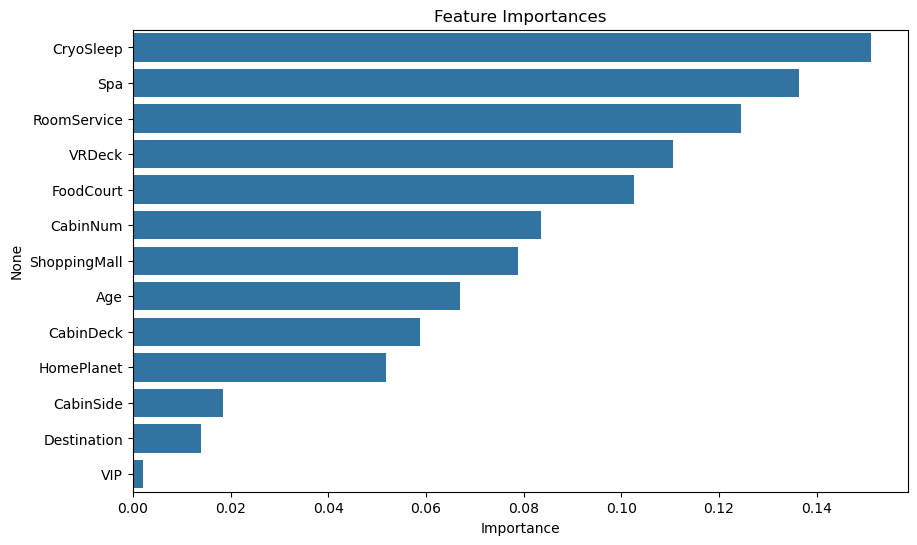


[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   1.6s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   1.6s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   1.8s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=300; total time=   2.4s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=2, n_estimators=300; total time=   2.3s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=5, n_esti

In [30]:
# 5. 결과 분석: 피처 중요도 확인
print("="*30)
print("피처 중요도 분석")
print("="*30)

# 어떤 변수가 예측에 가장 큰 영향을 미쳤는지 확인
importances = rf_model.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=forest_importances.values, y=forest_importances.index)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

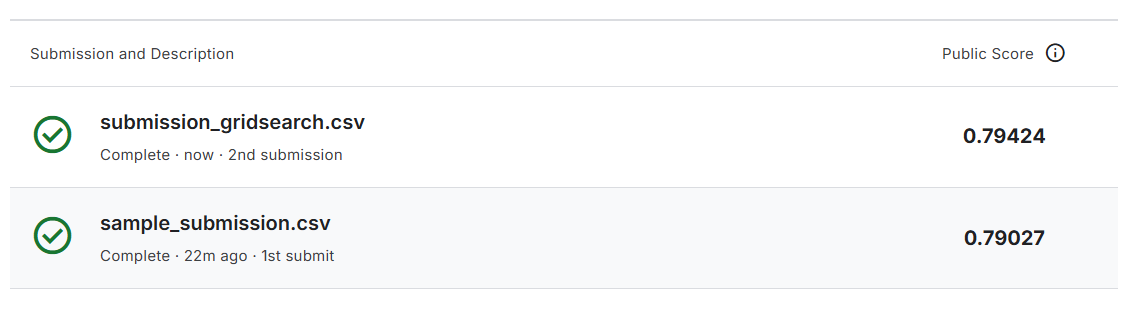

#### 후기  
##### GridSearchCV를 통해 하이퍼 파라미터 최적화를 진행하였고, 목표한 점수대는 아니었지만 소폭 개선된 것을 확인할 수 있었다.  
##### Ai의 도움을 받아 코딩하였기에 아직 자립적으로 코딩할 단계까지 도달하려면 더 많은 문제들을 풀어보며 복습을 해야 할 것 같다. 
